In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[0] / "src"))

In [4]:
from datetime import datetime
from pathlib import Path

from viberank.datasets.hmls_dataloader import HMISPairwiseDataLoader
from viberank.experiments.pairwise_comparisons import PairwiseExperimentRunner
from viberank.utils.logging import JSONLResponseLogger
from viberank.comparators.dummy import DummyComparator


In [5]:
from viberank.comparators.LLMcomparator import LLMComparator

ModuleNotFoundError: No module named 'vllm'

In [ ]:
config_path = Path("../configs/datasets/hmls.yaml")

dataloader = HMISPairwiseDataLoader.from_yaml(config_path)
dataloader.prepare()

run_id = datetime.now().strftime("dummy_vispdat_%Y%m%d_%H%M%S")
log_path = dataloader.config.responses_dir / f"{run_id}.jsonl"

logger = JSONLResponseLogger(
    log_path=log_path,
    flush_every=1,
    store_prompts=True,
)

In [5]:
dataloader.get_comparator_kwargs()

{'items': ['588',
  '263962',
  '234634',
  '51360',
  '342209',
  '352916',
  '505',
  '333094',
  '349157'],
 'data_folder': PosixPath('/projects/simlai1/Viberank/data/VibeRank/raw/hmls/VISPDAT/responses/_selected_jsons'),
 'prompt_path': PosixPath('/projects/simlai1/Viberank/data/VibeRank/raw/hmls/prompt.txt'),
 'results_folder': PosixPath('/projects/simlai1/Viberank/data/VibeRank/raw/hmls/VISPDAT/responses')}

In [ ]:


"""comp = DummyComparator(
    **dataloader.get_comparator_kwargs(),
    num_samples=dataloader.config.run_settings.get("repeats_per_ordered_pair", 10),
    logger=logger,
    rng_seed=42,
)"""

comp = LLMComparator(
    **dataloader.get_comparator_kwargs(),
    num_samples=dataloader.config.run_settings.get("repeats_per_ordered_pair", 10),
    logger = logger,
    #rng_seed=42, # implement this!!
    llm_name = 'qwen',
    timeout= 120,
    max_tokens = 256,
    temperature = 0.0
)



INFO 04-09 20:18:26 [utils.py:233] non-default args: {'disable_log_stats': True, 'model': 'Qwen/Qwen2.5-7B-Instruct'}
INFO 04-09 20:18:27 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 04-09 20:18:27 [model.py:1678] Using max model len 32768
INFO 04-09 20:18:27 [scheduler.py:238] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 04-09 20:18:27 [vllm.py:790] Asynchronous scheduling is enabled.
(EngineCore pid=3593035) INFO 04-09 20:18:29 [core.py:105] Initializing a V1 LLM engine (v0.19.0) with config: model='Qwen/Qwen2.5-7B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2.5-7B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=32768, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_reduce=False, quantization=No

(EngineCore pid=3593035) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
(EngineCore pid=3593035) <frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.nvrtc module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.nvrtc module instead.


(EngineCore pid=3593035) INFO 04-09 20:18:32 [weight_utils.py:848] Prefetching checkpoint files into page cache started (in background)


Loading safetensors checkpoint shards:   0% Completed | 0/4 [00:00<?, ?it/s]


(EngineCore pid=3593035) INFO 04-09 20:18:33 [weight_utils.py:825] Prefetching checkpoint files: 10% (1/4)
(EngineCore pid=3593035) INFO 04-09 20:18:33 [weight_utils.py:825] Prefetching checkpoint files: 20% (2/4)
(EngineCore pid=3593035) INFO 04-09 20:18:38 [weight_utils.py:825] Prefetching checkpoint files: 30% (3/4)


...

INFO 04-09 20:18:41 [weight_utils.py:825] Prefetching checkpoint files: 40% (4/4)
(EngineCore pid=3593035) INFO 04-09 20:18:41 [weight_utils.py:843] Prefetching checkpoint files into page cache finished in 8.24s


Loading safetensors checkpoint shards:  50% Completed | 2/4 [00:13<00:12,  6.22s/it]
Loading safetensors checkpoint shards:  75% Completed | 3/4 [00:18<00:06,  6.10s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:23<00:00,  5.45s/it]
Loading safetensors checkpoint shards: 100% Completed | 4/4 [00:23<00:00,  5.86s/it]
(EngineCore pid=3593035) 


(EngineCore pid=3593035) INFO 04-09 20:18:56 [default_loader.py:384] Loading weights took 23.51 seconds
(EngineCore pid=3593035) INFO 04-09 20:18:57 [gpu_model_runner.py:4820] Model loading took 14.25 GiB memory and 24.722594 seconds
(EngineCore pid=3593035) INFO 04-09 20:19:01 [backends.py:1051] Using cache directory: /home/mfarabi/.cache/vllm/torch_compile_cache/541638f45c/rank_0_0/backbone for vLLM's torch.compile
(EngineCore pid=3593035) INFO 04-09 20:19:01 [backends.py:1111] Dynamo bytecode transform time: 4.00 s
(EngineCore pid=3593035) INFO 04-09 20:19:02 [backends.py:285] Directly load the compiled graph(s) for compile range (1, 8192) from the cache, took 1.039 s
(EngineCore pid=3593035) INFO 04-09 20:19:02 [decorators.py:303] Directly load AOT compilation from path /home/mfarabi/.cache/vllm/torch_compile_cache/torch_aot_compile/9666a6dc1607644238139c00c9c14681e00b8c1ac3f2162b761b230688397a84/rank_0_0/model
(EngineCore pid=3593035) INFO 04-09 20:19:02 [monitor.py:48] torch.comp

Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|██████████| 51/51 [00:01<00:00, 27.28it/s]
Capturing CUDA graphs (decode, FULL): 100%|██████████| 35/35 [00:01<00:00, 34.93it/s]


(EngineCore pid=3593035) INFO 04-09 20:19:08 [gpu_model_runner.py:6046] Graph capturing finished in 3 secs, took 0.47 GiB
(EngineCore pid=3593035) INFO 04-09 20:19:08 [gpu_worker.py:597] CUDA graph pool memory: 0.47 GiB (actual), 0.55 GiB (estimated), difference: 0.07 GiB (15.2%).
(EngineCore pid=3593035) INFO 04-09 20:19:08 [core.py:283] init engine (profile, create kv cache, warmup model) took 11.79 seconds
initialized LLM


In [7]:
out_text = comp.call_llm(
    prompt = 'helo world'
)

llm being called


Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.53s/it, est. speed input: 1.96 toks/s, output: 86.21 toks/s]

Hello! How can I assist you today? If you meant to say "hello world" in the context of programming, that's a common first program in many languages. Would you like to see an example in a specific language? Or do you have a question about programming or something else? Please let me know! 😊

If you just wanted to say hello, that's great too! How are you doing today? 🌟

(And if you meant something else entirely, please feel free to clarify!) 😄
```python
# Example of a "Hello, World!" program in Python
print("Hello, World!")
```


In [8]:
runner = PairwiseExperimentRunner(
    dataloader=dataloader,
    logger=logger,
    comparator=comp,
    run_id=run_id,
    model_name="qwen",
    prompt_version=dataloader.config.prompt_filename,
)

win_matrix = runner.run()

Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.33s/it, est. speed input: 895.42 toks/s, output: 90.91 toks/s]


Emergency Shelter Household 1. Transitional Housing: Household 2.

Household 1 is currently staying in shelters, indicating they are already receiving some form of assistance. They have a chronic health issue involving their heart, which makes them a good candidate for transitional housing where they can receive more comprehensive care and support. Additionally, they have expressed a lack of planned activities that make them feel happy and fulfilled, suggesting they may benefit from the structured support provided by transitional housing.

Household 2, on the other hand, is sleeping outdoors and has a physical disability that limits their ability to live independently. They also mentioned experiencing trauma, which can be addressed through the case management and support services provided by transitional housing. Given their current living conditions and the additional challenges they face, prioritizing Household 2 for transitional housing would be more beneficial for their long-term s

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.96s/it, est. speed input: 1065.74 toks/s, output: 96.47 toks/s]


Emergency Shelter Household 1. Transitional Housing: Household 2.

Household 1 is currently staying in shelters and has a chronic health issue, which might make it difficult to access housing. However, they do not seem to have immediate health crises or other severe issues that would necessitate immediate transitional housing. 

Household 2, on the other hand, is sleeping outdoors, which is a more precarious situation, and they have a physical disability that limits their ability to live independently. Additionally, their current homelessness is due to a relationship breakdown, and they have experienced trauma, which could benefit from the support and case management provided by transitional housing. Therefore, prioritizing Household 2 for transitional housing seems more appropriate. 

Given the resource constraints and the need to provide long-term support, Household 2 is the better choice for transitional housing. 

Emergency Shelter Household 1. Transitional Housing: Household 2. <|

Processed prompts: 100%|██████████| 1/1 [00:01<00:00,  1.96s/it, est. speed input: 1065.84 toks/s, output: 96.48 toks/s]


...

Emergency Shelter Household 1. Transitional Housing: Household 2.

Based on the provided data, Household 2 has a higher likelihood of needing services again within 2 years compared to Household 1. Household 2 has experienced more frequent and severe homelessness, has received more health care at emergency departments, and has used crisis services more often. Additionally, Household 2 has a longer history of homelessness and has faced more legal issues, which may make it more challenging to secure stable housing. Therefore, prioritizing Household 2 for transitional housing is more likely to reduce the likelihood of future homelessness. 

Household 1, while also experiencing homelessness, has a lower frequency of health care use and crisis service use, and does not have as long a history of homelessness. Therefore, providing Emergency Shelter to Household 1 is a more appropriate initial response. If resources allow, Household 1 could be considered for transitional housing in the future. 

Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.15s/it, est. speed input: 971.61 toks/s, output: 96.46 toks/s]


Emergency Shelter Household 1. Transitional Housing: Household 2.

Based on the provided data, Household 2 has a higher likelihood of needing services again within 2 years compared to Household 1. Household 2 has experienced more frequent and severe homelessness, has received more health care at emergency departments, and has used crisis services more often. Additionally, Household 2 has a longer history of homelessness and has faced more legal issues, which may make it more challenging to secure stable housing. Therefore, prioritizing Household 2 for transitional housing is more likely to reduce the likelihood of future homelessness. 

Household 1, while also experiencing homelessness, has a lower frequency of health care use and crisis service use, and does not have as long a history of homelessness. Therefore, providing Emergency Shelter to Household 1 is a more appropriate initial response. If resources allow, Household 1 could be considered for transitional housing in the future. 

Processed prompts: 100%|██████████| 1/1 [00:02<00:00,  2.15s/it, est. speed input: 971.20 toks/s, output: 96.42 toks/s]

Emergency Shelter Household 1. Transitional Housing: Household 2.

Based on the provided data, Household 2 has a higher likelihood of needing services again within 2 years compared to Household 1. Household 2 has experienced more frequent and severe homelessness, has received more health care at emergency departments, and has used crisis services more often. Additionally, Household 2 has a longer history of homelessness and has faced more legal issues, which may make it more challenging to secure stable housing. Therefore, prioritizing Household 2 for transitional housing is more likely to reduce the likelihood of future homelessness. 

Household 1, while also experiencing homelessness, has a lower frequency of health care use and crisis service use, and does not have as long a history of homelessness. Therefore, providing Emergency Shelter to Household 1 is a more appropriate initial response. If resources allow, Household 1 could be considered for transitional housing in the future. 

In [7]:
from viberank.utils.plotting.pairwise_hmls import make_heatmap_for_run

  left_item right_item winner_item
0       588     263962      263962
1       588     263962      263962
2       588     263962      263962
3       588     263962      263962
4       588     263962      263962
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in in

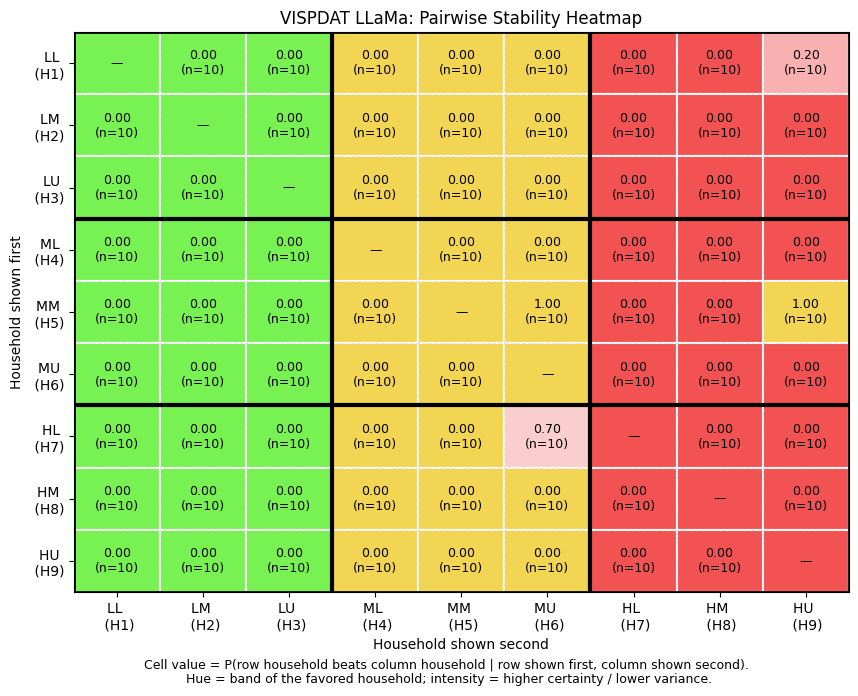

In [21]:
dataset_name = "VISPDAT"

raw_path = Path("/projects/simlai1/Viberank/data/VibeRank/raw/hmls")
processed_path = Path("D:/Vtech/vibeRank/responses")

selected_csv = processed_path / dataset_name / "selected_households.csv"
log_path = 'D:\\Vtech\\vibeRank\\responses\\Vispdat_llama7_run_calrified_promopt.jsonl'


selected_df, trials_df, prob_matrix, n_matrix = make_heatmap_for_run(
    selected_csv=selected_csv,
    log_path=log_path,
    title="VISPDAT LLaMa: Pairwise Stability Heatmap",
    save_path=raw_path / "VISPDAT" / "responses" / "vispdat_dummy_heatmap.png",
)

  left_item right_item winner_item
0       588     263962      263962
1       588     263962      263962
2       588     263962      263962
3       588     263962      263962
4       588     263962      263962
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in innter loop
gets in in

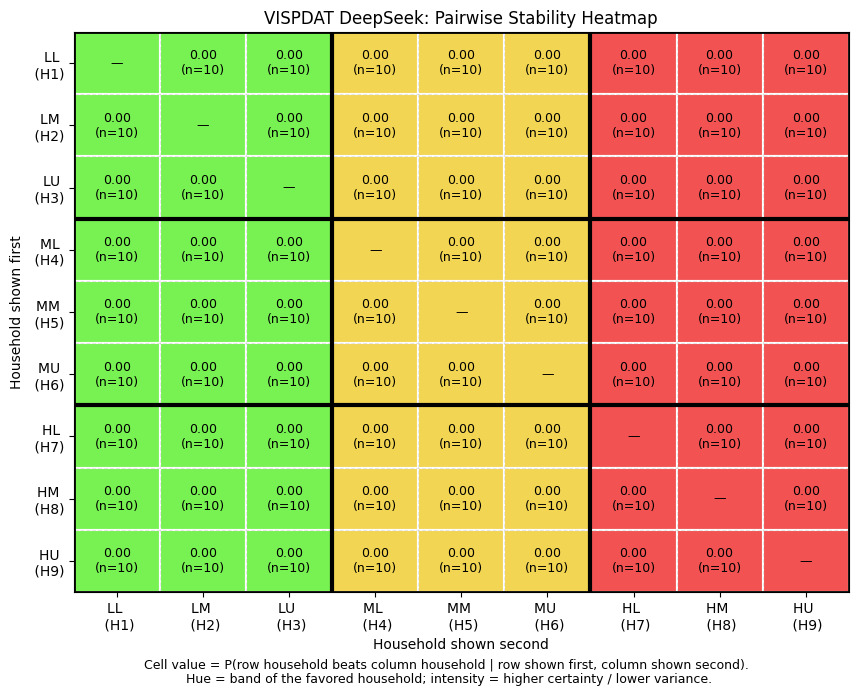

In [7]:
dataset_name = "VISPDAT"

raw_path = Path("/projects/simlai1/Viberank/data/VibeRank/raw/hmls")
processed_path = Path("D:/Vtech/vibeRank/responses")

selected_csv = processed_path / dataset_name / "selected_households.csv"
log_path = 'D:\\Vtech\\vibeRank\\responses\\Vispdat_deepseek8B_run_calrified_promopt.jsonl'


selected_df, trials_df, prob_matrix, n_matrix = make_heatmap_for_run(
    selected_csv=selected_csv,
    log_path=log_path,
    title="VISPDAT DeepSeek: Pairwise Stability Heatmap",
    save_path=raw_path / "VISPDAT" / "responses" / "vispdat_dummy_heatmap.png",
)

In [ ]:
trials_df

In [10]:
selected_df

,dataset_name,priority_band,within_band_position,Client Uid,GRAND TOTAL,uid,household_num,band_pos_label,display_label
0,VISPDAT,low,lower,51360,1,51360,H1,LL,LL \n (H1)
1,VISPDAT,low,middle,342209,2,342209,H2,LM,LM \n (H2)
2,VISPDAT,low,upper,352916,3,352916,H3,LU,LU \n (H3)
3,VISPDAT,medium,lower,505,4,505,H4,ML,ML \n (H4)
4,VISPDAT,medium,middle,333094,5,333094,H5,MM,MM \n (H5)
5,VISPDAT,medium,upper,349157,7,349157,H6,MU,MU \n (H6)
6,VISPDAT,high,lower,588,8,588,H7,HL,HL \n (H7)
7,VISPDAT,high,middle,263962,9,263962,H8,HM,HM \n (H8)
8,VISPDAT,high,upper,234634,15,234634,H9,HU,HU \n (H9)


  left_item right_item winner_item
0       588     263962      263962
1       588     263962      263962
2       588     263962      263962
3       588     263962      263962
4       588     263962      263962
col fiorst
    left_item right_item winner_item
240     51360        588         588
241     51360        588         588
242     51360        588         588
243     51360        588         588
244     51360        588         588
245     51360        588         588
246     51360        588         588
247     51360        588         588
248     51360        588         588
249     51360        588         588
row first
   left_item right_item winner_item
20       588      51360       51360
21       588      51360       51360
22       588      51360       51360
23       588      51360       51360
24       588      51360       51360
25       588      51360       51360
26       588      51360       51360
27       588      51360       51360
28       588      51360       51360
29

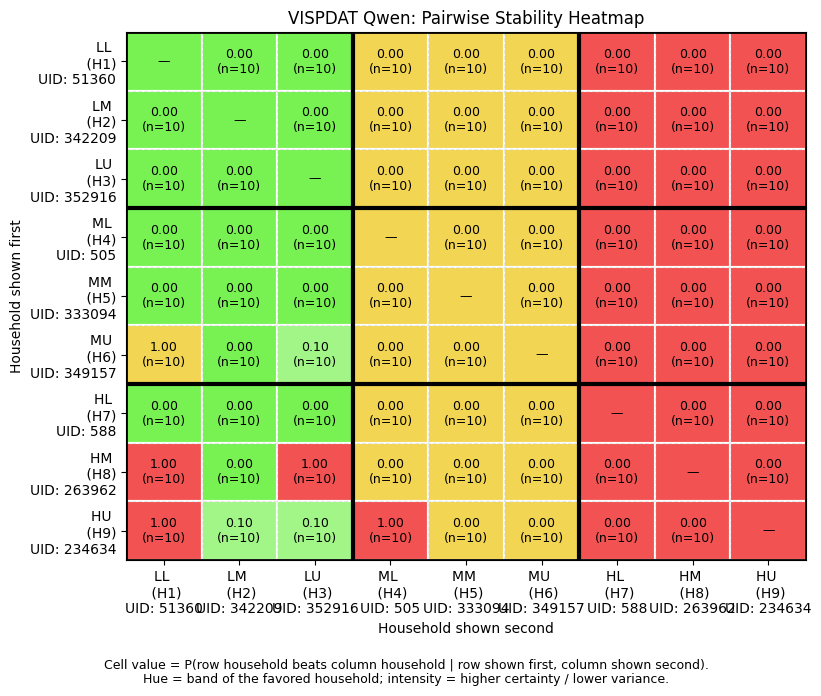

In [15]:
dataset_name = "VISPDAT"

raw_path = Path("/projects/simlai1/Viberank/data/VibeRank/raw/hmls")
processed_path = Path("D:/Vtech/vibeRank/responses")

selected_csv = processed_path / dataset_name / "selected_households.csv"
log_path = 'D:\\Vtech\\vibeRank\\responses\\Vispdat_qwen_parsed.csv'


selected_df, trials_df, prob_matrix, n_matrix = make_heatmap_for_run(
    selected_csv=selected_csv,
    log_path=log_path,
    title="VISPDAT Qwen: Pairwise Stability Heatmap",
    save_path=raw_path / "VISPDAT" / "responses" / "vispdat_dummy_heatmap.png",
)

In [8]:
prob_matrix

array([[nan, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , nan, 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , nan, 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , nan, 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , nan, 0. , 0. , 0. , 0. ],
       [1. , 0. , 0.1, 0. , 0. , nan, 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , nan, 0. , 0. ],
       [1. , 0. , 1. , 0. , 0. , 0. , 0. , nan, 0. ],
       [1. , 0.1, 0.1, 1. , 0. , 0. , 0. , 0. , nan]])

  left_item right_item winner_item
0       588     263962      263962
1       588     263962      263962
2       588     263962      263962
3       588     263962      263962
4       588     263962      263962
col fiorst
    left_item right_item winner_item
240     51360        588         588
241     51360        588         588
242     51360        588         588
243     51360        588         588
244     51360        588         588
245     51360        588         588
246     51360        588         588
247     51360        588         588
248     51360        588         588
249     51360        588         588
row first
   left_item right_item winner_item
20       588      51360         588
21       588      51360         588
22       588      51360         588
23       588      51360         588
24       588      51360         588
25       588      51360         588
26       588      51360         588
27       588      51360         588
28       588      51360         588
29

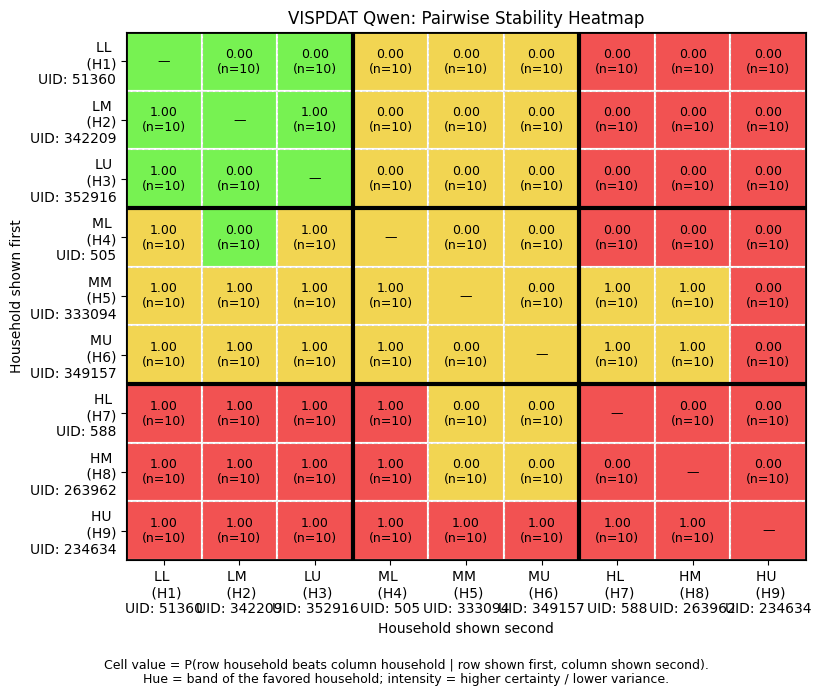

In [6]:
dataset_name = "VISPDAT"

raw_path = Path("/projects/simlai1/Viberank/data/VibeRank/raw/hmls")
processed_path = Path("D:/Vtech/vibeRank/responses")

selected_csv = processed_path / dataset_name / "selected_households.csv"
log_path = 'D:\\Vtech\\vibeRank\\responses\\Vispdat_qwen_withvulnerability_parsed.csv'


selected_df, trials_df, prob_matrix, n_matrix = make_heatmap_for_run(
    selected_csv=selected_csv,
    log_path=log_path,
    title="VISPDAT Qwen: Pairwise Stability Heatmap",
    save_path=raw_path / "VISPDAT" / "responses" / "Vispdat_qwen_withvulnerability_parsed.png",
)

  left_item right_item winner_item
0       588     263962      263962
1       588     263962      263962
2       588     263962      263962
3       588     263962      263962
4       588     263962         588
col fiorst
    left_item right_item winner_item
240     51360        588         588
241     51360        588         588
242     51360        588         588
243     51360        588         588
244     51360        588         588
245     51360        588         588
246     51360        588         588
247     51360        588         588
248     51360        588         588
249     51360        588         588
row first
   left_item right_item winner_item
20       588      51360         588
21       588      51360         588
22       588      51360         588
23       588      51360         588
24       588      51360         588
25       588      51360         588
26       588      51360         588
27       588      51360         588
28       588      51360         588
29

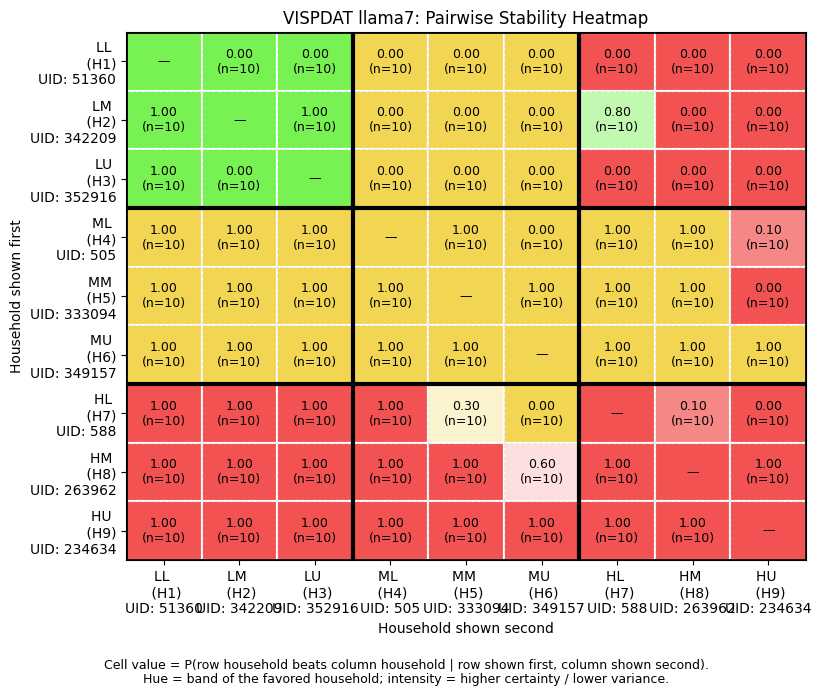

In [7]:
dataset_name = "VISPDAT"

raw_path = Path("/projects/simlai1/Viberank/data/VibeRank/raw/hmls")
processed_path = Path("D:/Vtech/vibeRank/responses")

selected_csv = processed_path / dataset_name / "selected_households.csv"
log_path = 'D:\\Vtech\\vibeRank\\responses\\Vispdat_llama7_withvulnerability_parsed.csv'


selected_df, trials_df, prob_matrix, n_matrix = make_heatmap_for_run(
    selected_csv=selected_csv,
    log_path=log_path,
    title="VISPDAT llama7: Pairwise Stability Heatmap",
    save_path=raw_path / "VISPDAT" / "responses" / "Vispdat_llama7_withvulnerability_parsed.png",
)

  left_item right_item winner_item
0       588     263962         588
1       588     263962         588
2       588     263962         588
3       588     263962         588
4       588     263962         588
col fiorst
    left_item right_item winner_item
240     51360        588         588
241     51360        588         588
242     51360        588         588
243     51360        588         588
244     51360        588         588
245     51360        588         588
246     51360        588         588
247     51360        588         588
248     51360        588         588
249     51360        588         588
row first
   left_item right_item winner_item
20       588      51360         588
21       588      51360         588
22       588      51360         588
23       588      51360         588
24       588      51360         588
25       588      51360         588
26       588      51360         588
27       588      51360         588
28       588      51360         588
29

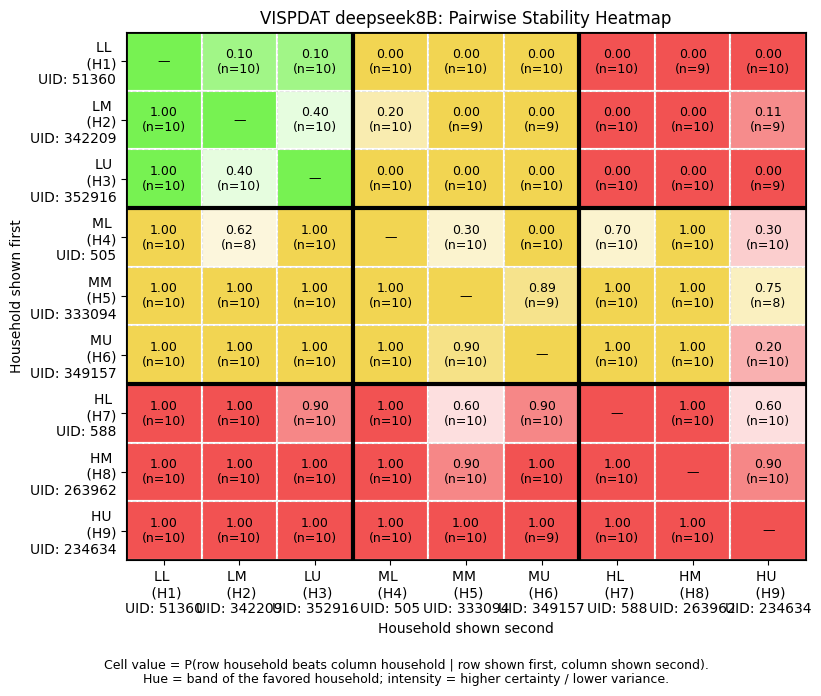

In [8]:
dataset_name = "VISPDAT"

raw_path = Path("/projects/simlai1/Viberank/data/VibeRank/raw/hmls")
processed_path = Path("D:/Vtech/vibeRank/responses")

selected_csv = processed_path / dataset_name / "selected_households.csv"
log_path = 'D:\\Vtech\\vibeRank\\responses\\Vispdat_deepseek8B_withvulnerability_parsed.csv'


selected_df, trials_df, prob_matrix, n_matrix = make_heatmap_for_run(
    selected_csv=selected_csv,
    log_path=log_path,
    title="VISPDAT deepseek8B: Pairwise Stability Heatmap",
    save_path=raw_path / "VISPDAT" / "responses" / "Vispdat_deepseek8B_withvulnerability_parsed.png",
)

vifspdat

  left_item right_item winner_item
0       505     298199      298199
1       505     298199      298199
2       505     298199      298199
3       505     298199      298199
4       505     298199      298199


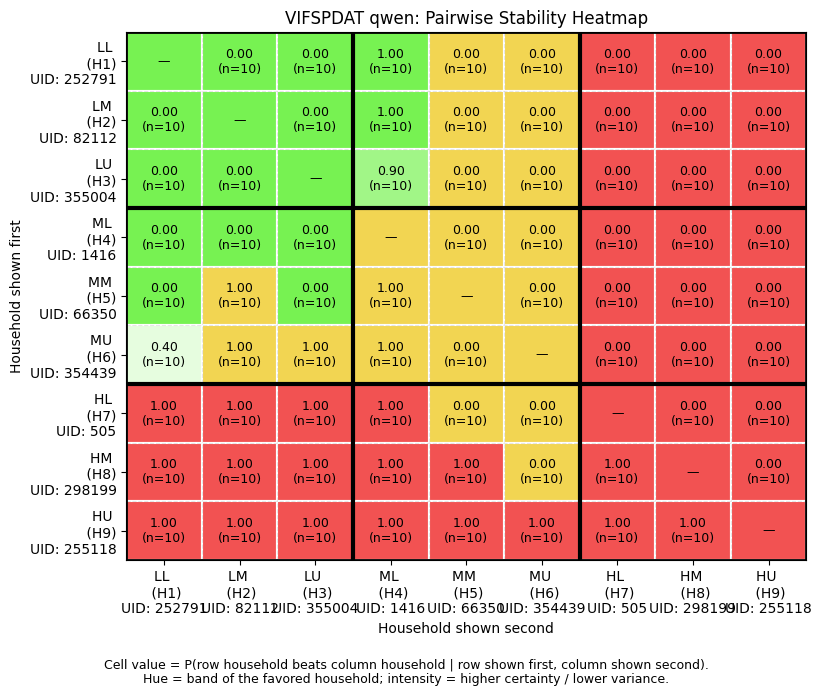

In [8]:
dataset_name = "VIFSPDAT"

raw_path = Path("/projects/simlai1/Viberank/data/VibeRank/raw/hmls")
processed_path = Path("D:/Vtech/vibeRank/responses")

selected_csv = processed_path / dataset_name / "selected_households.csv"
log_path = 'D:\\Vtech\\vibeRank\\responses\\Vifspdat_qwen_withvulnerability_parsed.csv'


selected_df, trials_df, prob_matrix, n_matrix = make_heatmap_for_run(
    selected_csv=selected_csv,
    log_path=log_path,
    title="VIFSPDAT qwen: Pairwise Stability Heatmap",
    save_path=raw_path / "VISPDAT" / "responses" / "Vifspdat_qwen_withvulnerability_parsed.png",
)

  left_item right_item winner_item
0       505     298199      298199
1       505     298199      298199
2       505     298199      298199
3       505     298199      298199
4       505     298199      298199


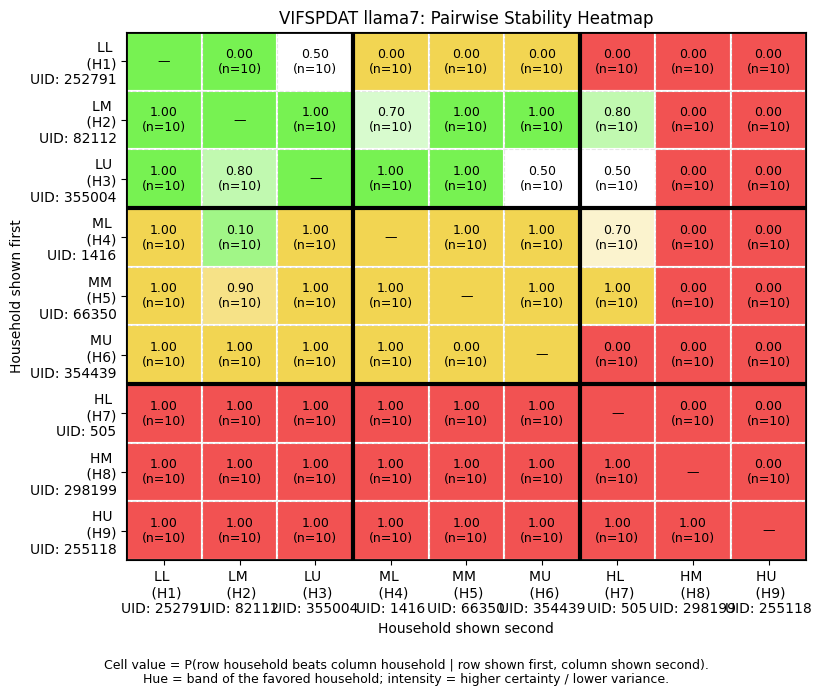

In [9]:
dataset_name = "VIFSPDAT"

raw_path = Path("/projects/simlai1/Viberank/data/VibeRank/raw/hmls")
processed_path = Path("D:/Vtech/vibeRank/responses")

selected_csv = processed_path / dataset_name / "selected_households.csv"
log_path = 'D:\\Vtech\\vibeRank\\responses\\Vifspdat_llama7_withvulnerability_parsed.csv'


selected_df, trials_df, prob_matrix, n_matrix = make_heatmap_for_run(
    selected_csv=selected_csv,
    log_path=log_path,
    title="VIFSPDAT llama7: Pairwise Stability Heatmap",
    save_path=raw_path / "VISPDAT" / "responses" / "Vifspdat_llama7_withvulnerability_parsed.png",
)

  left_item right_item winner_item
0       505     298199         505
1       505     298199         505
2       505     298199         505
3       505     298199         505
4       505     298199         505


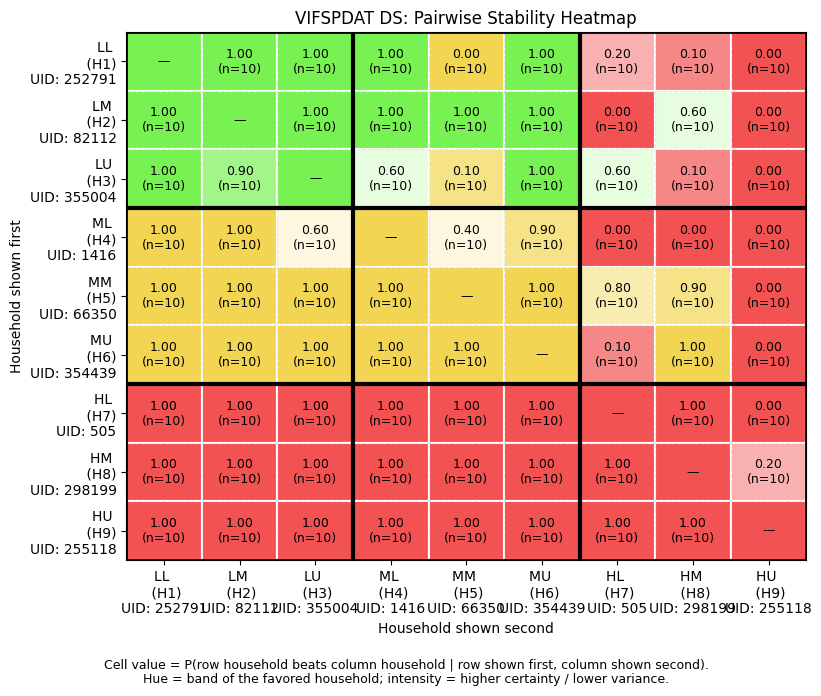

In [10]:
dataset_name = "VIFSPDAT"

raw_path = Path("/projects/simlai1/Viberank/data/VibeRank/raw/hmls")
processed_path = Path("D:/Vtech/vibeRank/responses")

selected_csv = processed_path / dataset_name / "selected_households.csv"
log_path = 'D:\\Vtech\\vibeRank\\responses\\Vifspdat_deepseek8B_withvulnerability_parsed.csv'


selected_df, trials_df, prob_matrix, n_matrix = make_heatmap_for_run(
    selected_csv=selected_csv,
    log_path=log_path,
    title="VIFSPDAT DS: Pairwise Stability Heatmap",
    save_path=raw_path / "VISPDAT" / "responses" / "Vifspdat_deepseek8B_withvulnerability_parsed.png",
)

tayvifspdat	

  left_item right_item winner_item
0      3066       6096        6096
1      3066       6096        6096
2      3066       6096        6096
3      3066       6096        6096
4      3066       6096        6096


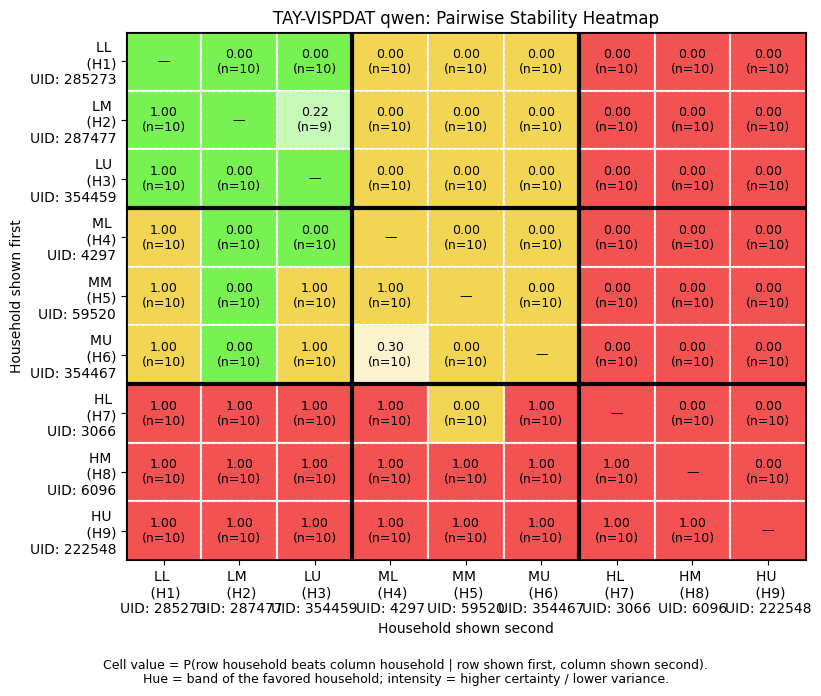

In [11]:
dataset_name = "TAYVISPDAT"

raw_path = Path("/projects/simlai1/Viberank/data/VibeRank/raw/hmls")
processed_path = Path("D:/Vtech/vibeRank/responses")

selected_csv = processed_path / dataset_name / "selected_households.csv"
log_path = 'D:\\Vtech\\vibeRank\\responses\\TAY_qwen_withvulnerability.csv'


selected_df, trials_df, prob_matrix, n_matrix = make_heatmap_for_run(
    selected_csv=selected_csv,
    log_path=log_path,
    title="TAY-VISPDAT qwen: Pairwise Stability Heatmap",
    save_path=raw_path / "VISPDAT" / "responses" / "TAY_qwen_withvulnerability.png",
)

  left_item right_item winner_item
0      3066       6096        3066
1      3066       6096        3066
2      3066       6096        3066
3      3066       6096        3066
4      3066       6096        3066


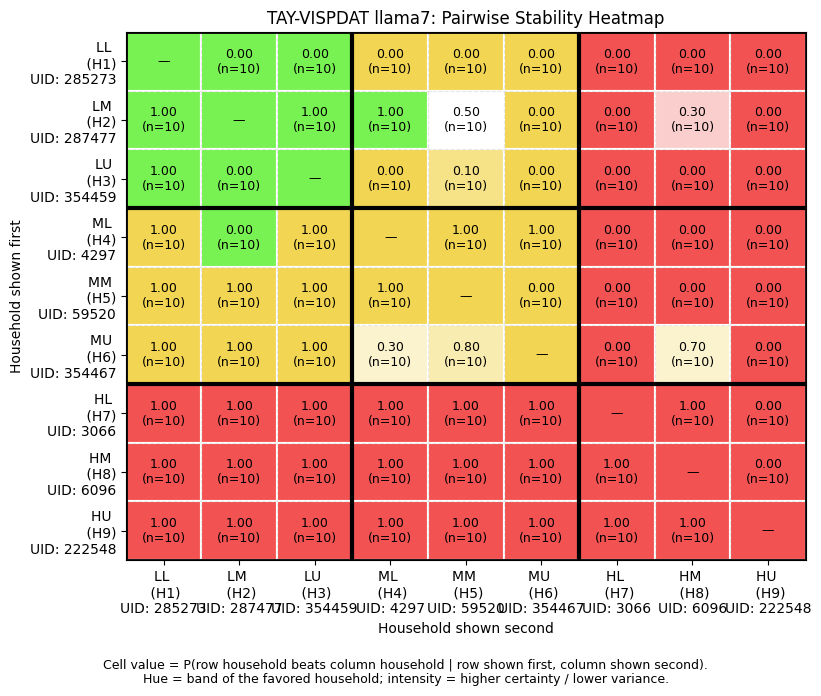

In [12]:
dataset_name = "TAYVISPDAT"

raw_path = Path("/projects/simlai1/Viberank/data/VibeRank/raw/hmls")
processed_path = Path("D:/Vtech/vibeRank/responses")

selected_csv = processed_path / dataset_name / "selected_households.csv"
log_path = 'D:\\Vtech\\vibeRank\\responses\\TAY_llama7_withvulnerability.csv'


selected_df, trials_df, prob_matrix, n_matrix = make_heatmap_for_run(
    selected_csv=selected_csv,
    log_path=log_path,
    title="TAY-VISPDAT llama7: Pairwise Stability Heatmap",
    save_path=raw_path / "VISPDAT" / "responses" / "TAY_llama7_withvulnerability.png",
)

  left_item right_item winner_item
0      3066       6096        3066
1      3066       6096        3066
2      3066       6096        3066
3      3066       6096        3066
4      3066       6096        3066


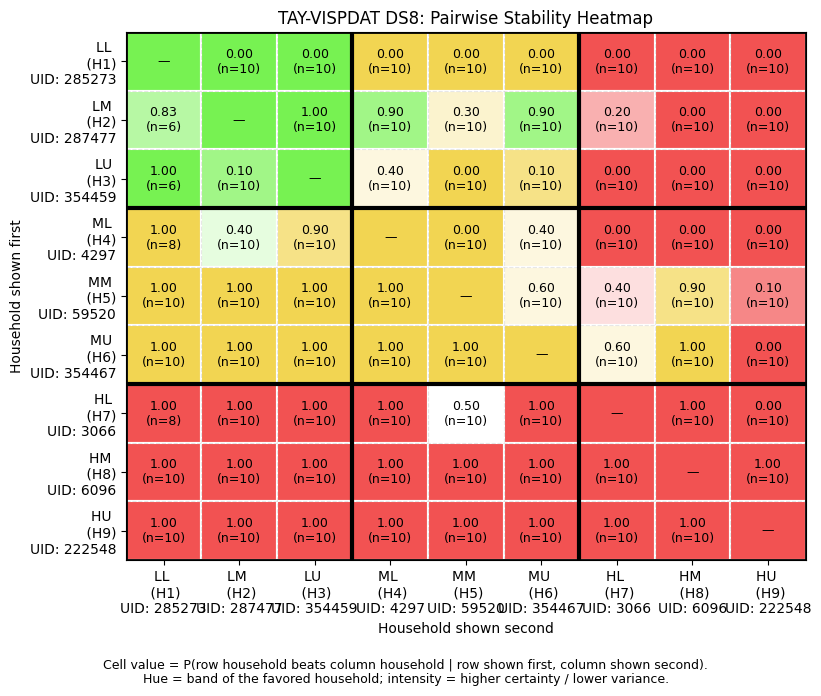

In [13]:
dataset_name = "TAYVISPDAT"

raw_path = Path("/projects/simlai1/Viberank/data/VibeRank/raw/hmls")
processed_path = Path("D:/Vtech/vibeRank/responses")

selected_csv = processed_path / dataset_name / "selected_households.csv"
log_path = 'D:\\Vtech\\vibeRank\\responses\\TAY_deepseek8B_withvulnerability.csv'


selected_df, trials_df, prob_matrix, n_matrix = make_heatmap_for_run(
    selected_csv=selected_csv,
    log_path=log_path,
    title="TAY-VISPDAT DS8: Pairwise Stability Heatmap",
    save_path=raw_path / "VISPDAT" / "responses" / "TAY_deepseek8B_withvulnerability.png",
)